In [1]:
# ruff: noqa: F405
%cd /lustre/scratch126/gengen/teams_v2/marks/dp31/elia/spatialPeeler/demo

from _shared import pl_k_sP, psc_ds, run_deg_groups, run_nmf, run_proc_per_ds, viz_defs, comp_spat_stats  # isort:skip

from functools import partial
from pathlib import Path
from pickle import dump, load
from warnings import catch_warnings, simplefilter

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import uapl
import upsetplot as up
from matplotlib import pyplot as plt
from plotnine import *  # noqa: F403

import spatialpeeler as sP
from spatialpeeler.diag import comp_sparsity, sweep_uns

/lustre/scratch126/gengen/teams_v2/marks/dp31/elia/spatialPeeler/demo


/lustre/scratch126/gengen/teams_v2/marks/dp31/elia/spatialPeeler/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
viz_defs(dpi=128)
RAND_SEED = 28
# define helper function for plotting
pl_help = partial(pl_k_sP, cond_col="group", sample_col="sample_id", ctl_val="CTL")
SP_FACT_PAT_STR = "sP_p_hat_k={k}"
SP_GENE_PAT_STR = "sp_gene_id_k={k}"

CASE_KS = [4, 11, 7, 15, 1, 24, 13, 22, 27]
CTL_KS = [6, 8, 5, 10, 2, 9, 0, 12, 17, 24]

scar_i = [1]
edge = [4, 24, 27]
smoothmuscle = [7]
zonation = [2, 6]

CASE_KS = scar_i + edge + smoothmuscle 
CTL_KS = zonation
print(f"CASE_KS: {CASE_KS}")
print(f"CTL_KS: {CTL_KS}")

CASE_KS: [1, 4, 24, 27, 7]
CTL_KS: [2, 6]


In [3]:
# load dataset + run NMF
if (pth := Path("../.cache/psc.pkl")).exists():
    with open(pth, "rb") as f:
        psc = load(f)
else:
    adatas = psc_ds(
        Path("../data/psc-visium"),
    )
    for k in adatas:
        adatas[k] = adatas[k][adatas[k].obs["in_tissue"], :]

    run_proc_per_ds(adatas)

    psc = ad.concat(adatas, label="sample_id", index_unique="_")

    sc.pp.filter_genes(psc, min_cells=psc.n_obs // 500)

    psc.var["SYMBOL"] = (
        sc.queries.biomart_annotations("hsapiens", ["ensembl_gene_id", "external_gene_name"], host="grch37.ensembl.org")
        .set_index("ensembl_gene_id")
        .merge(psc.var.index.to_series(), left_index=True, right_index=True, how="right")["external_gene_name"]
        .fillna(psc.var.index.to_series())
    )

    run_nmf(psc, 30, RAND_SEED)

    pth.parent.mkdir(exist_ok=True)
    with open(pth, "wb") as f:
        dump(psc, f)
print(psc)

AnnData object with n_obs × n_vars = 21553 × 16465
    obs: 'in_tissue', 'percent.mt', 'cell_type', 'group', 'sample_id'
    var: 'n_cells', 'SYMBOL'
    obsm: 'spatial', 'X_nmf'
    varm: 'X_nmf'
    layers: 'counts'


In [4]:
sample_id_map = {
    "C73_A": "CTL_A",
    "C73_B": "CTL_B",
    "C73_C": "CTL_C",
    "C73_D": "CTL_D",
    "PSC011_A": "PSC_A",
    "PSC011_B": "PSC_B",
    "PSC011_C": "PSC_C",
    "PSC011_D": "PSC_D",
}

psc.obs["sample_id"] = (
    psc.obs["sample_id"]
    .map(sample_id_map)
    .astype("category")
    .cat.reorder_categories(list(sample_id_map.values()))
)


In [5]:
# run factor-wise regression step
for k in range(psc.obsm["X_nmf"].shape[1]):
    sP.run_fact_reg(psc, "group", "CTL", k, SP_FACT_PAT_STR.format(k=k), X_key="X_nmf")

print(psc)

AnnData object with n_obs × n_vars = 21553 × 16465
    obs: 'in_tissue', 'percent.mt', 'cell_type', 'group', 'sample_id'
    var: 'n_cells', 'SYMBOL'
    uns: 'sP_p_hat_k=0', 'sP_p_hat_k=1', 'sP_p_hat_k=2', 'sP_p_hat_k=3', 'sP_p_hat_k=4', 'sP_p_hat_k=5', 'sP_p_hat_k=6', 'sP_p_hat_k=7', 'sP_p_hat_k=8', 'sP_p_hat_k=9', 'sP_p_hat_k=10', 'sP_p_hat_k=11', 'sP_p_hat_k=12', 'sP_p_hat_k=13', 'sP_p_hat_k=14', 'sP_p_hat_k=15', 'sP_p_hat_k=16', 'sP_p_hat_k=17', 'sP_p_hat_k=18', 'sP_p_hat_k=19', 'sP_p_hat_k=20', 'sP_p_hat_k=21', 'sP_p_hat_k=22', 'sP_p_hat_k=23', 'sP_p_hat_k=24', 'sP_p_hat_k=25', 'sP_p_hat_k=26', 'sP_p_hat_k=27', 'sP_p_hat_k=28', 'sP_p_hat_k=29'
    obsm: 'spatial', 'X_nmf', 'sP_p_hat_k=0', 'sP_p_hat_k=1', 'sP_p_hat_k=2', 'sP_p_hat_k=3', 'sP_p_hat_k=4', 'sP_p_hat_k=5', 'sP_p_hat_k=6', 'sP_p_hat_k=7', 'sP_p_hat_k=8', 'sP_p_hat_k=9', 'sP_p_hat_k=10', 'sP_p_hat_k=11', 'sP_p_hat_k=12', 'sP_p_hat_k=13', 'sP_p_hat_k=14', 'sP_p_hat_k=15', 'sP_p_hat_k=16', 'sP_p_hat_k=17', 'sP_p_hat_k=18',

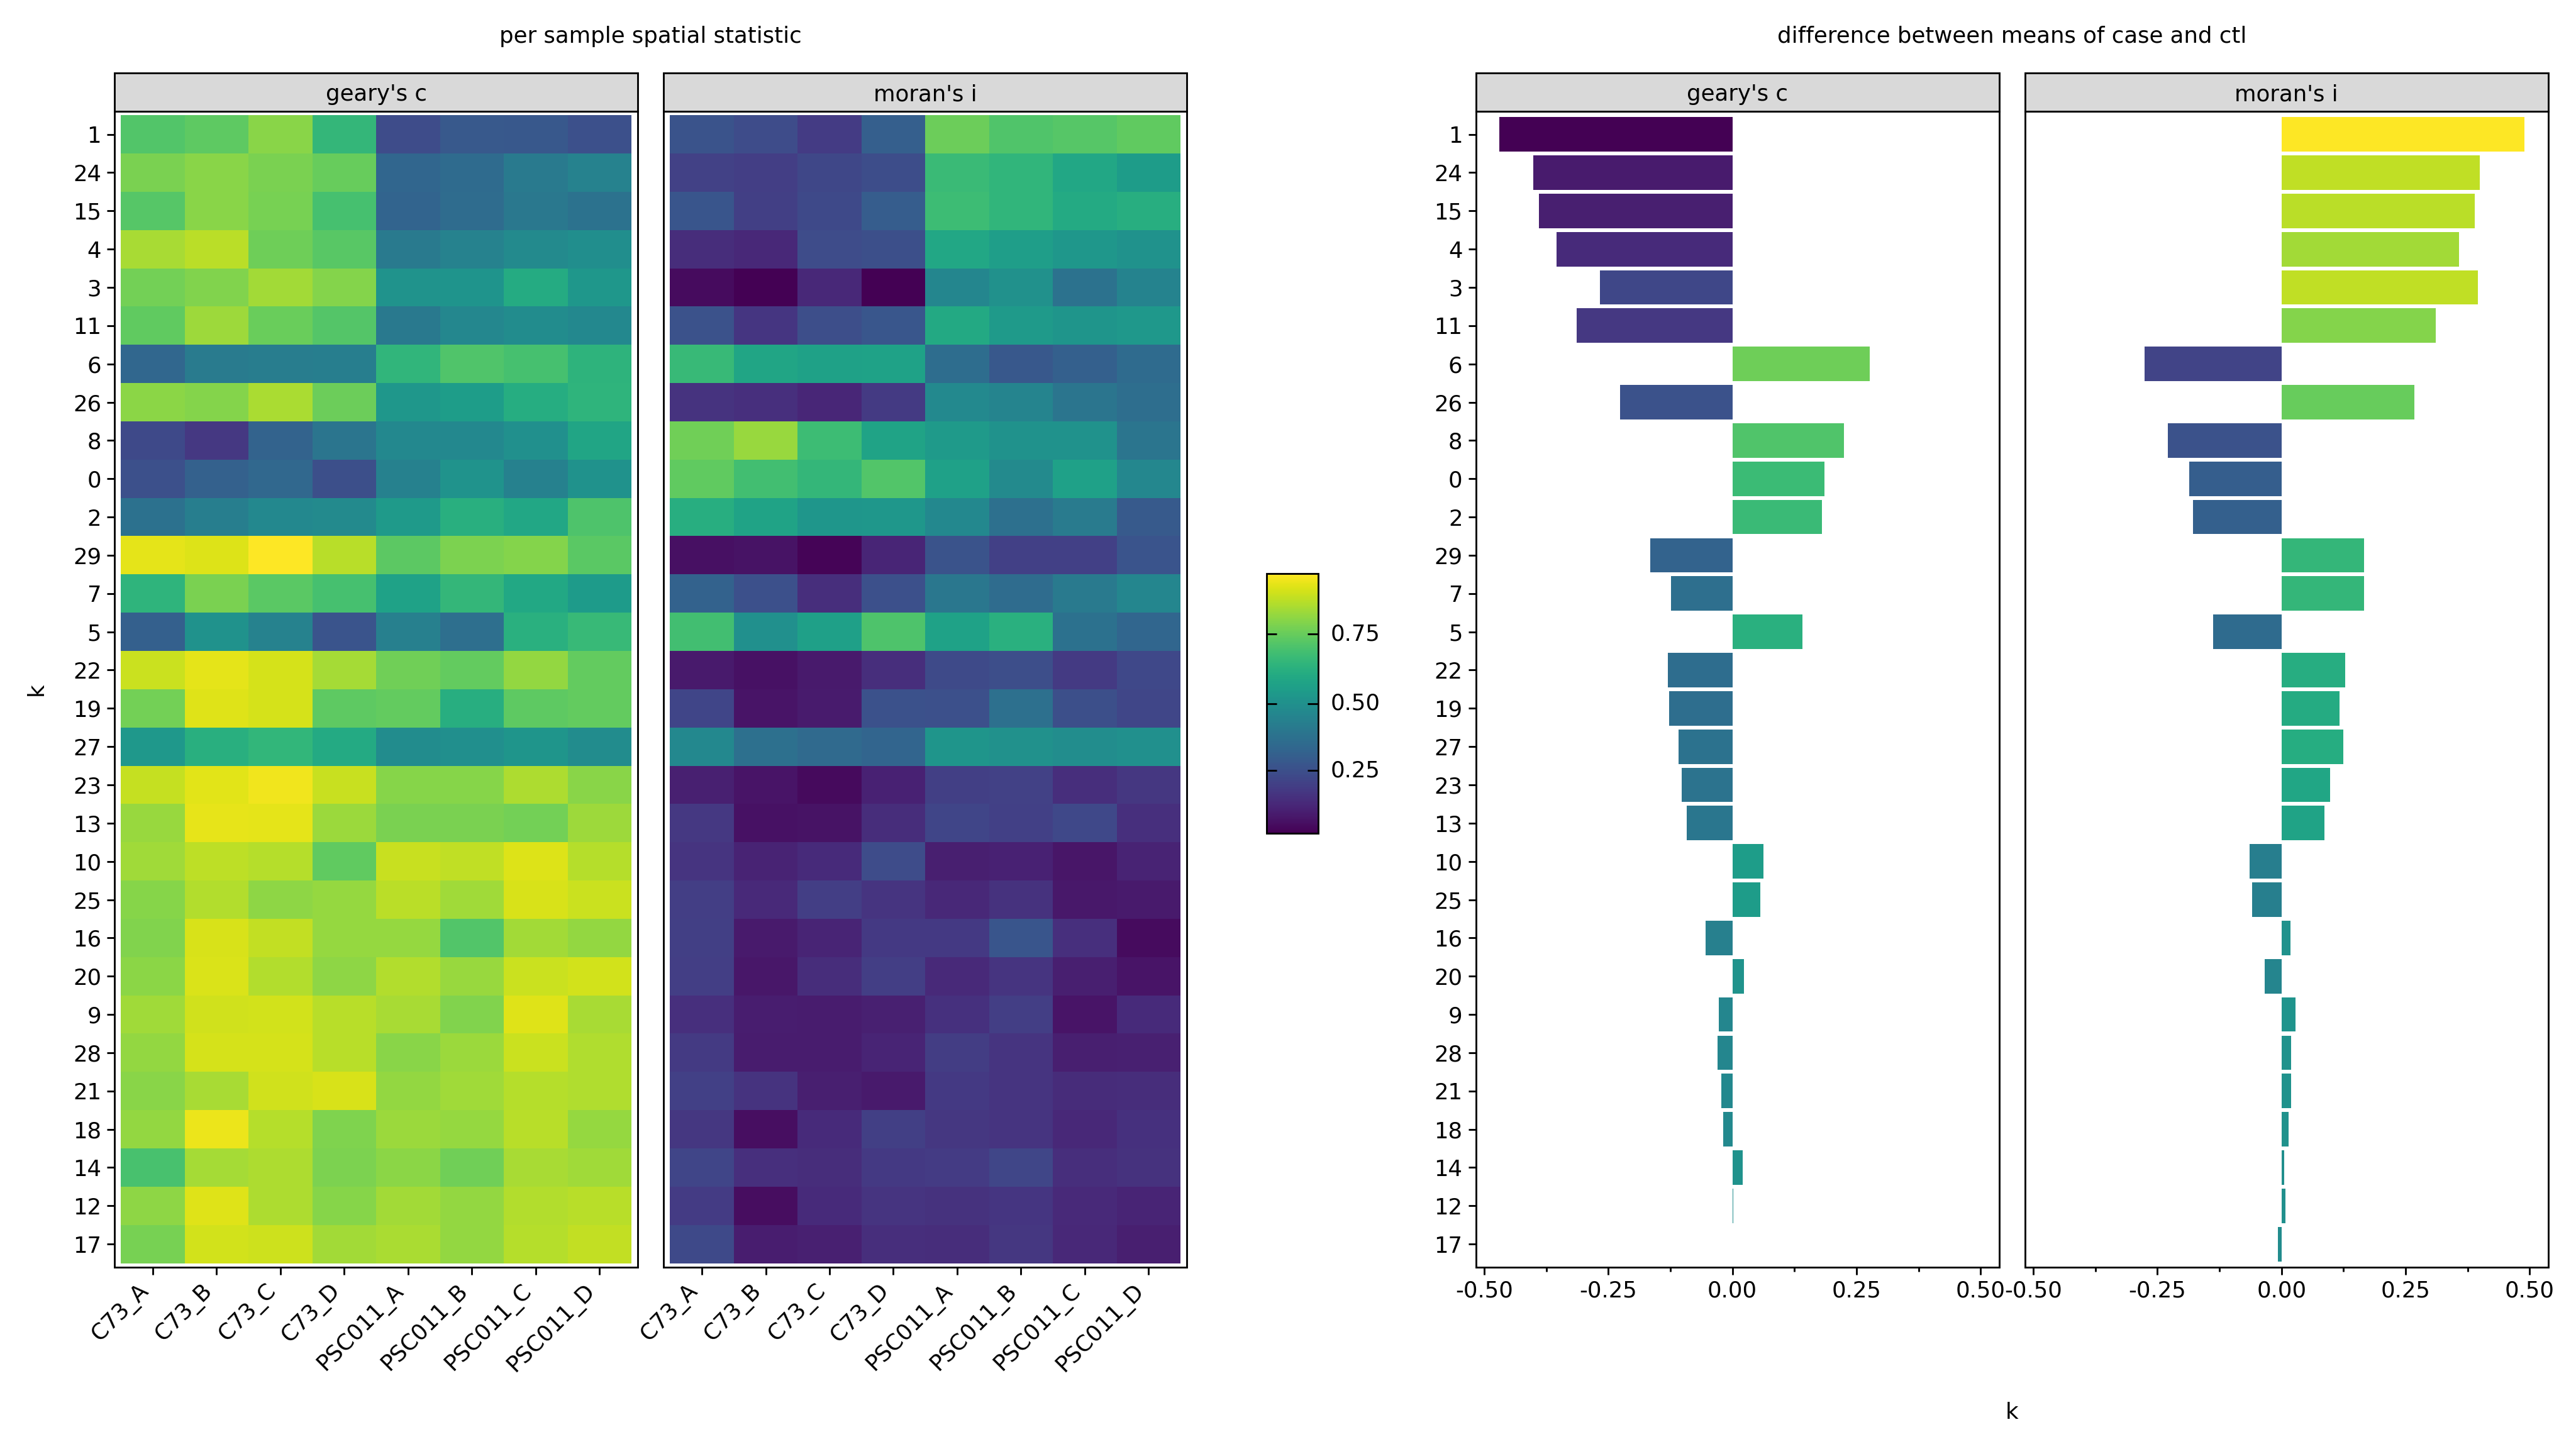

In [12]:
psc.raw = None  # drop raw to avoid copying the full sparse matrix on every AnnData slice in comp_spat_stats
sp_stat_df, sp_stat_pl = comp_spat_stats(psc, SP_FACT_PAT_STR, "sample_id", "group", "CTL")
(sp_stat_pl & theme(figure_size=(16, 9))).show()  # ty:ignore[unsupported-operator]

In [13]:
sp_stat_df

,k,stat,sample,is_case,val,diff
0,0,moran's i,C73_A,False,0.745339,-0.185607
1,0,geary's c,C73_A,False,0.251788,0.184925
2,1,moran's i,C73_A,False,0.261348,0.489463
3,1,geary's c,C73_A,False,0.718101,-0.469080
4,2,moran's i,C73_A,False,0.621489,-0.178160
...,...,...,...,...,...,...
475,27,geary's c,PSC011_D,True,0.482280,-0.108424
476,28,moran's i,PSC011_D,True,0.100676,0.019048
477,28,geary's c,PSC011_D,True,0.864587,-0.029912
478,29,moran's i,PSC011_D,True,0.265620,0.166454


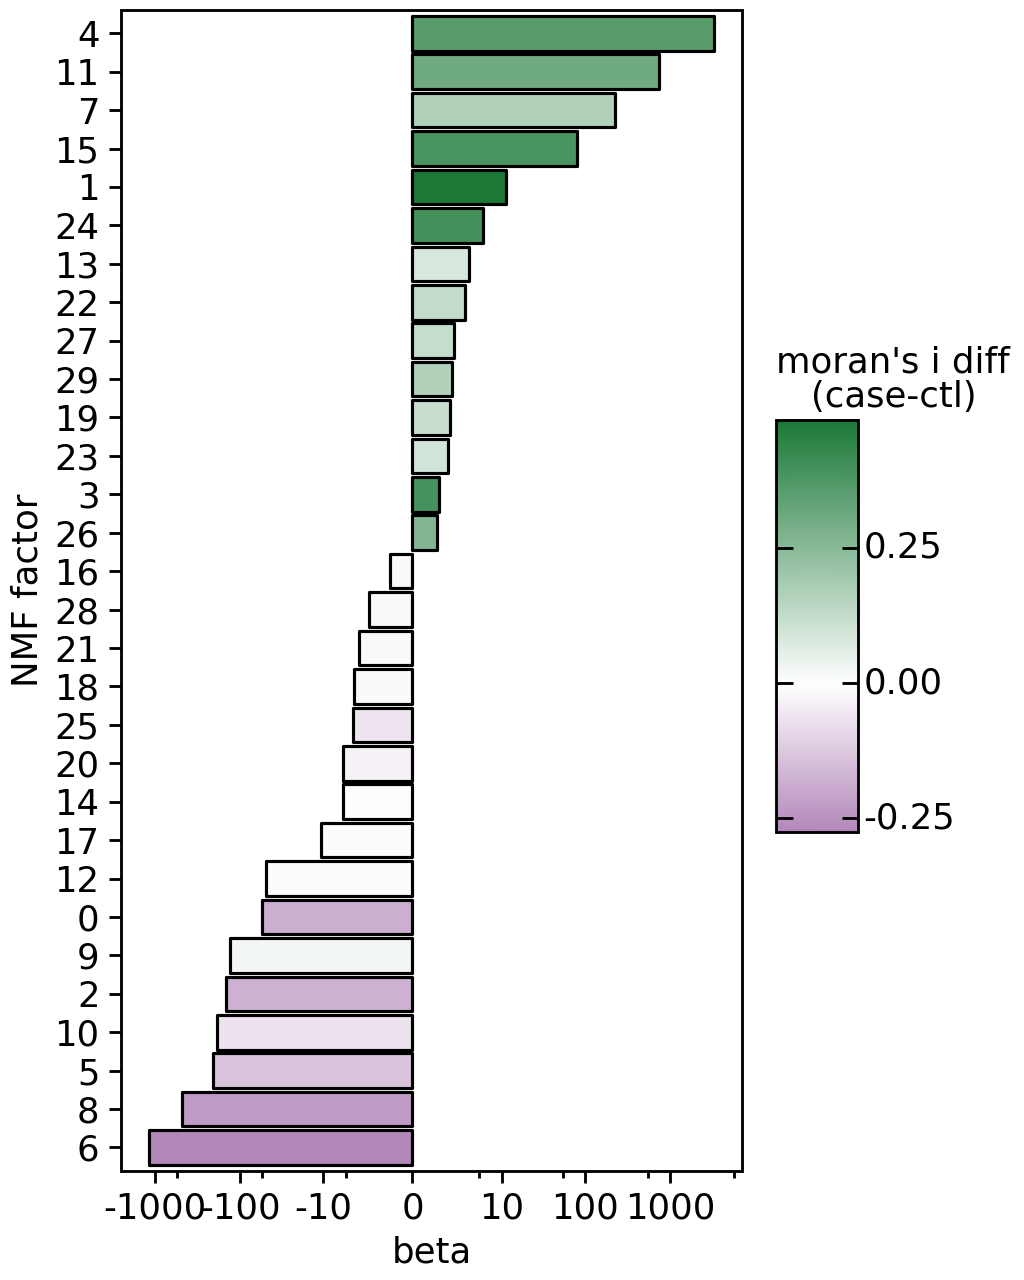

/lustre/scratch126/gengen/teams_v2/marks/dp31/elia/spatialPeeler/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 4 x 5 in image.
/lustre/scratch126/gengen/teams_v2/marks/dp31/elia/spatialPeeler/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /lustre/scratch126/gengen/teams_v2/marks/dp31/elia/spatialPeeler/figures/psc/psc_moran_diff.pdf


In [6]:
sp_stat_df, sp_stat_pl = comp_spat_stats(psc, SP_FACT_PAT_STR, "sample_id", "group", "CTL")

moran_diff = (
    sp_stat_df.query("stat == \"moran's i\"")[["k", "diff"]]
    .drop_duplicates()
    .assign(k=lambda d: d["k"].astype(str))  # sweep_uns's "k" is captured as a string
)

'''
(
    sweep_uns(psc, SP_FACT_PAT_STR)
    .merge(moran_diff, on="k")
    >> ggplot()
    + aes(x="reorder(k, beta)", fill="diff", y="beta")
    + geom_col(color="black")
    + coord_flip()
    + labs(fill="moran's i diff\n(case-ctl)", x="NMF factor")
    + scale_fill_cmap("PRGn") #BuGn
    + scale_y_symlog()
    + theme(figure_size=(4, 5))  # (width, height) in inches

).show()
'''
p_moran_diff = (
    sweep_uns(psc, SP_FACT_PAT_STR)
    .merge(moran_diff, on="k")
    >> ggplot()
    + aes(x="reorder(k, beta)", fill="diff", y="beta")
    + geom_col(color="black")
    + coord_flip()
    + labs(fill="moran's i diff\n(case-ctl)", x="NMF factor")
    + scale_fill_gradient2(low="#762a83", mid="white", high="#1b7837", midpoint=0)
    + scale_y_symlog()
    + theme(figure_size=(4, 5))  # (width, height) in inches
)

p_moran_diff.show()

fig_dir = Path("/lustre/scratch126/gengen/teams_v2/marks/dp31/elia/spatialPeeler/figures/psc/")
fig_dir.mkdir(exist_ok=True)
p_moran_diff.save(fig_dir / "psc_moran_diff.pdf")





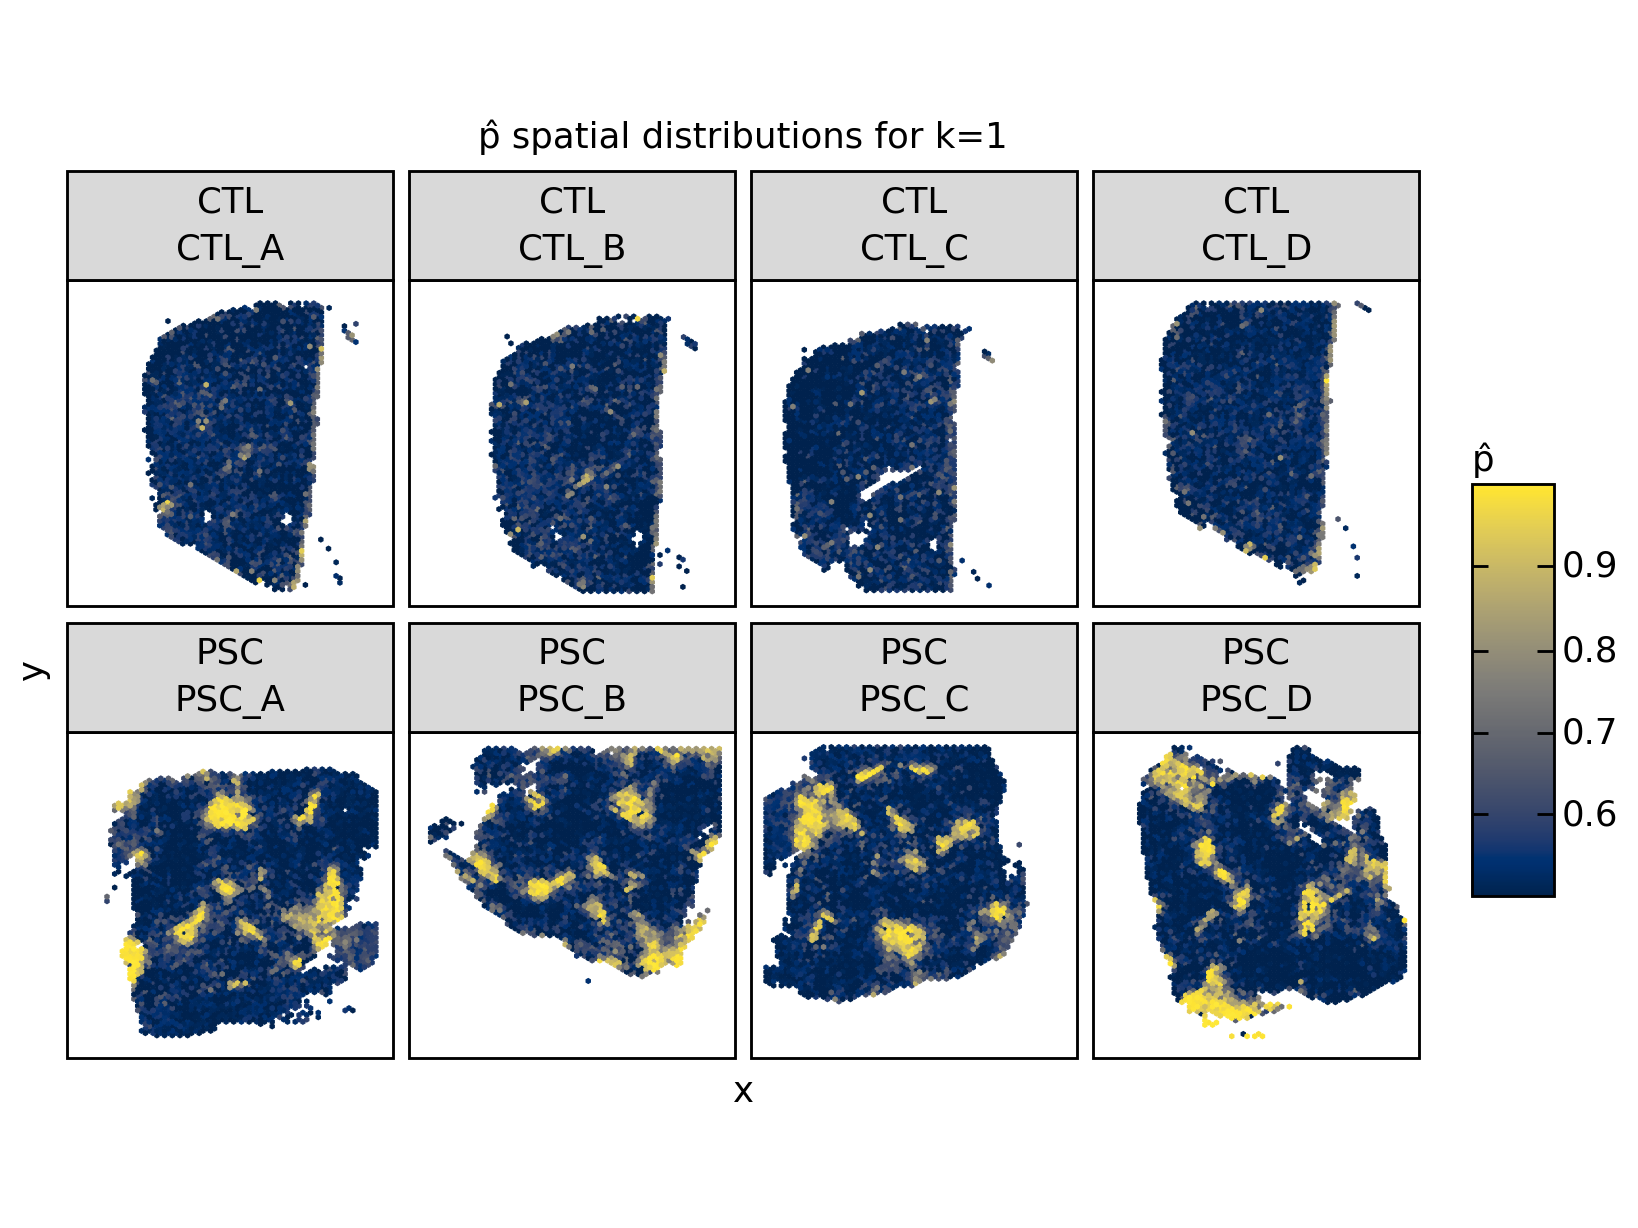

/lustre/scratch126/gengen/teams_v2/marks/dp31/elia/spatialPeeler/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8.3 x 6 in image.
/lustre/scratch126/gengen/teams_v2/marks/dp31/elia/spatialPeeler/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /lustre/scratch126/gengen/teams_v2/marks/dp31/elia/spatialPeeler/figures/psc/psc_cnt_k=1_spatial_p-hat_1.png


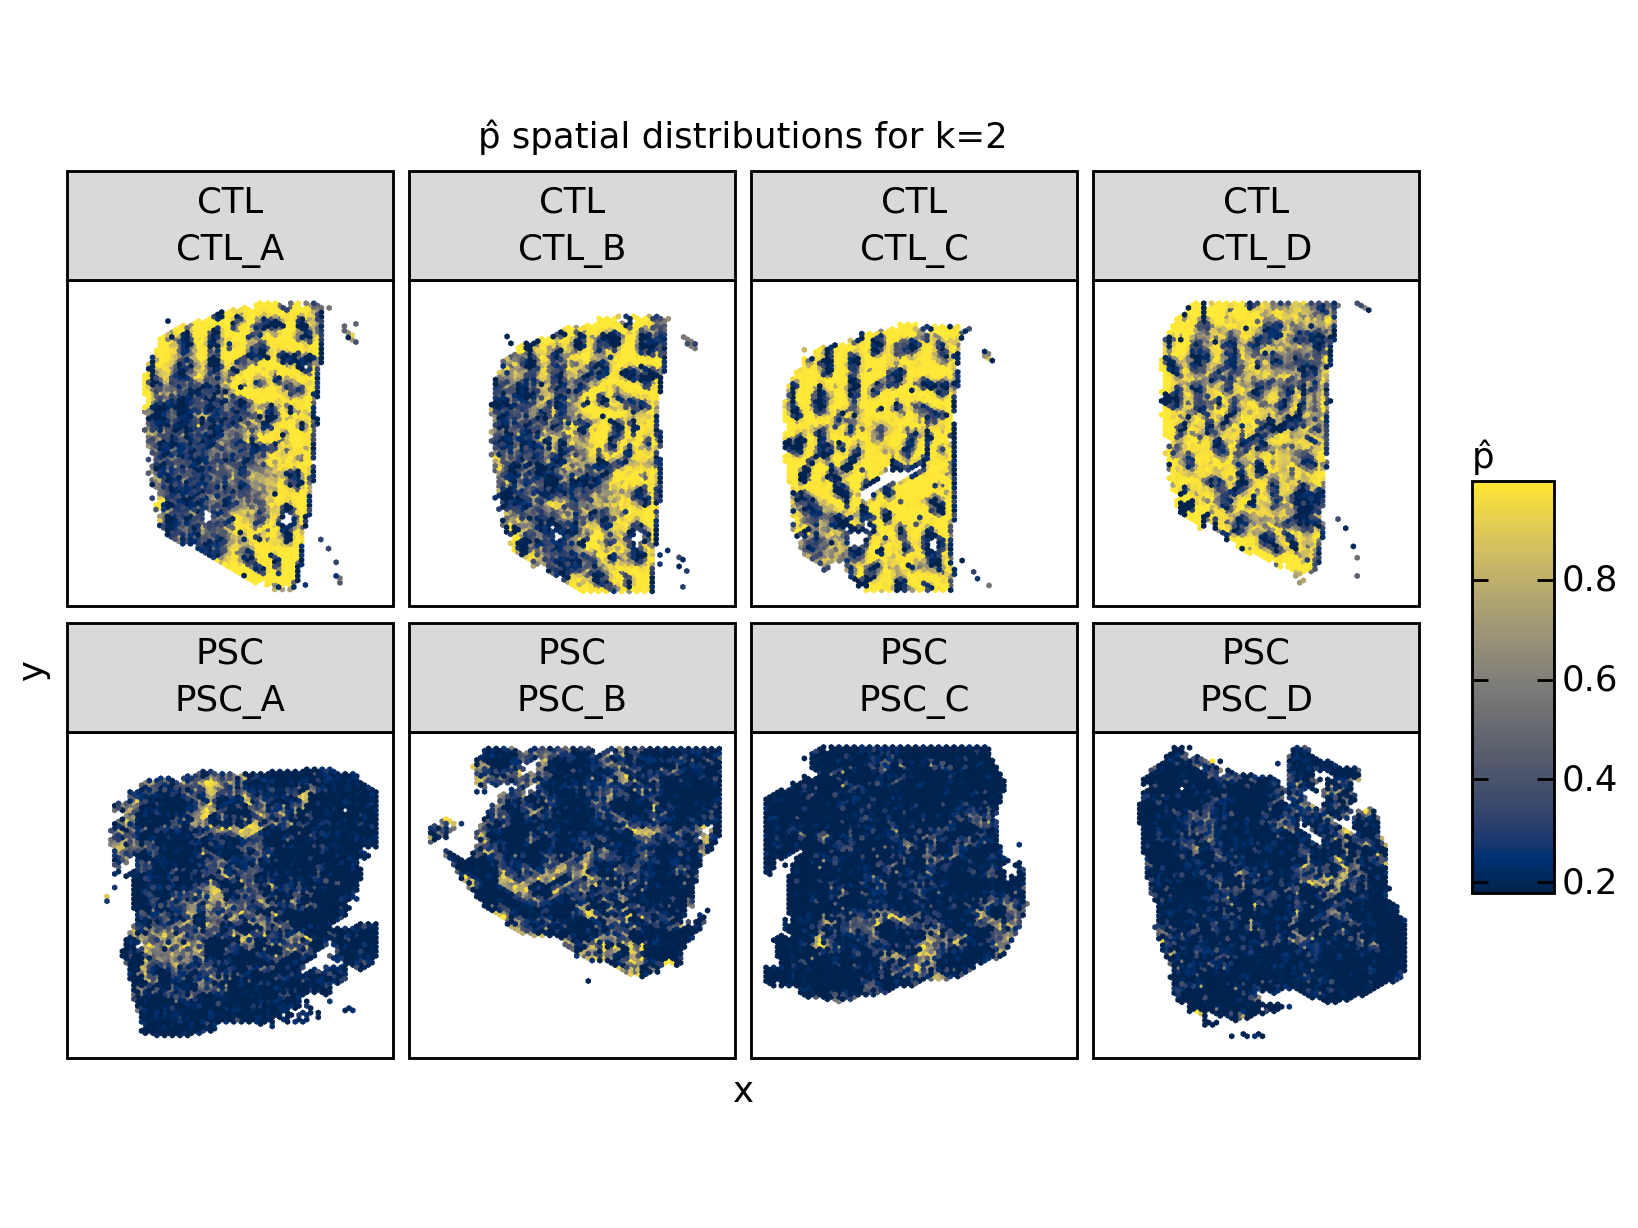

/lustre/scratch126/gengen/teams_v2/marks/dp31/elia/spatialPeeler/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8.3 x 6 in image.
/lustre/scratch126/gengen/teams_v2/marks/dp31/elia/spatialPeeler/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /lustre/scratch126/gengen/teams_v2/marks/dp31/elia/spatialPeeler/figures/psc/psc_cnt_k=2_spatial_p-hat_1.png


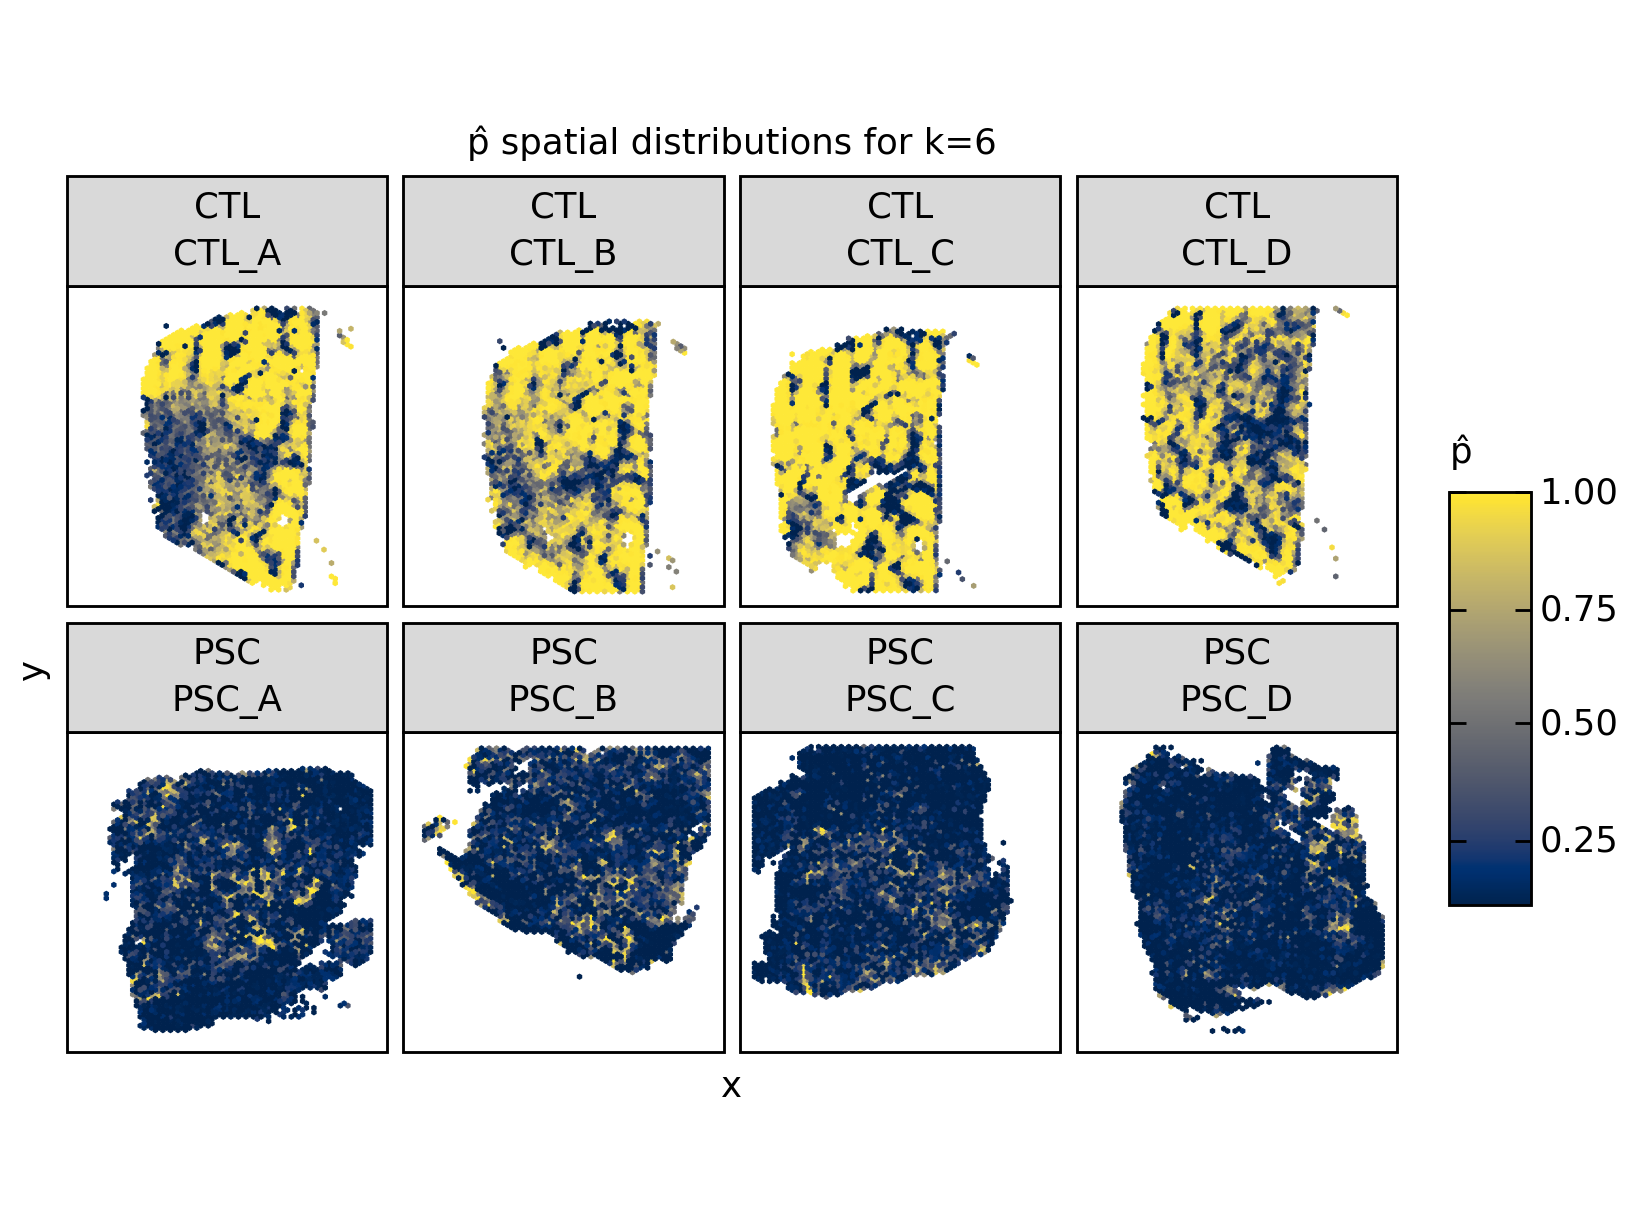

/lustre/scratch126/gengen/teams_v2/marks/dp31/elia/spatialPeeler/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8.3 x 6 in image.
/lustre/scratch126/gengen/teams_v2/marks/dp31/elia/spatialPeeler/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /lustre/scratch126/gengen/teams_v2/marks/dp31/elia/spatialPeeler/figures/psc/psc_cnt_k=6_spatial_p-hat_1.png


In [22]:
#for k in CASE_KS:
#    for p in pl_help(psc, k).values():
#        p.show()

fig_dir = Path("/lustre/scratch126/gengen/teams_v2/marks/dp31/elia/spatialPeeler/figures/psc/")

for k in [1, 2, 6]:#CASE_KS[:1]:
    counter = 0
    for name, p in pl_help(psc, k).items():
        p.show()

        safe_name = name.replace(" ", "_").replace("/", "-")
        counter += 1
        #p.save(fig_dir / f"psc_case_k={k}_{safe_name}_{counter}.png", dpi=300)
        p.save(fig_dir / f"psc_cnt_k={k}_{safe_name}_{counter}.png", width=8.3, height=6, dpi=300)
        if counter == 1:
            break





In [25]:
phat_genes = pd.read_csv("../.cache/top_phat_genes_psc.csv")

k = 1
print(f"k={k}")
display(phat_genes.loc[phat_genes["k"] == k].drop(columns="k").head(25))

k=1


,group,rank,gene,SYMBOL,corr,wcorr
16465,case,1,ENSG00000251562,MALAT1,0.732070,0.720381
16466,case,2,ENSG00000107317,PTGDS,0.573985,0.554022
16467,case,3,ENSG00000077942,FBLN1,0.569351,0.567052
16468,case,4,ENSG00000026025,VIM,0.563991,0.635341
16469,case,5,ENSG00000106624,AEBP1,0.556145,0.576501
16470,case,6,ENSG00000164692,COL1A2,0.530083,0.548573
16471,case,7,ENSG00000091986,CCDC80,0.529446,0.539216
16472,case,8,ENSG00000187955,COL14A1,0.517068,0.549217
16473,case,9,ENSG00000163453,IGFBP7,0.511873,0.611272
16474,case,10,ENSG00000112936,C7,0.510127,0.586776


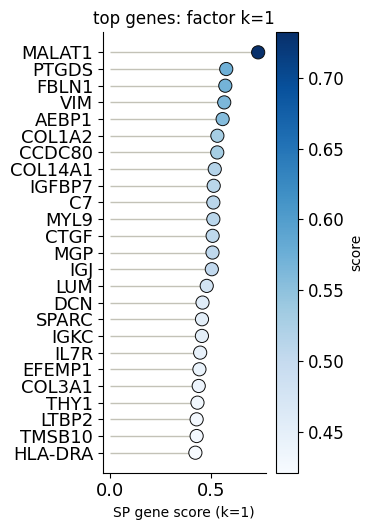

In [17]:
k = 1
N_TOP = 25

#scores = pd.Series(psc.varm["X_nmf"][:, k], index=psc.var_names, name="score")
## make score pandas using: phat_genes.loc[phat_genes["k"] == k].drop(columns="k")
scores = pd.Series(
    phat_genes.loc[phat_genes["k"] == k].drop(columns="k").set_index("SYMBOL")["corr"].sort_values(ascending=False),

) 
top_genes = (
    scores.sort_values(ascending=False)
    .head(N_TOP)
    .rename(index=psc.var["SYMBOL"])
    .sort_values()  # ascending so the highest score plots at the top
)

fig, ax = plt.subplots(figsize=(3.7, 5.4))
sca = ax.scatter(
    top_genes.values, np.arange(len(top_genes)),
    c=top_genes.values, cmap="Blues", s=90,
    edgecolors="#0b0b0b", linewidths=0.7, zorder=3,
)
ax.hlines(np.arange(len(top_genes)), 0, top_genes.values, 
color="#c3c2b7", linewidth=1, zorder=1)
ax.set_yticks(np.arange(len(top_genes)))
ax.set_yticklabels(top_genes.index, fontsize=13)      # gene names
ax.tick_params(axis="x", labelsize=13)                 # x-axis tick numbers
ax.set_xlabel(f"SP gene score (k={k})")
ax.set_title(f"top genes: factor k={k}")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
cbar = fig.colorbar(sca, ax=ax, label="score")  # colorbar label
cbar.ax.tick_params(labelsize=12)                      # colorbar tick numbers
fig.tight_layout()


fig.savefig(fig_dir / f"psc_top_genes_k={k}.pdf", dpi=300, bbox_inches="tight")
plt.show()



In [26]:
print(CTL_KS)

for k in CTL_KS:
    #for p in pl_help(psc, k).values():
    #    p.show()
    print(f"k={k}")
    display(phat_genes.loc[phat_genes["k"] == k].drop(columns="k").head(25))

[2, 6]
k=2


,group,rank,gene,SYMBOL,corr,wcorr
32930,control,1,ENSG00000118271,TTR,0.629408,0.533797
32931,control,2,ENSG00000138115,CYP2C8,0.620525,0.522002
32932,control,3,ENSG00000124713,GNMT,0.615735,0.523513
32933,control,4,ENSG00000172482,AGXT,0.614320,0.526292
32934,control,5,ENSG00000115457,IGFBP2,0.610358,0.501073
32935,control,6,ENSG00000166825,ANPEP,0.609814,0.515275
32936,control,7,ENSG00000160862,AZGP1,0.607105,0.529734
32937,control,8,ENSG00000143416,SELENBP1,0.605422,0.516683
32938,control,9,ENSG00000228278,ORM2,0.604461,0.514345
32939,control,10,ENSG00000106258,CYP3A5,0.603010,0.504655


k=6


,group,rank,gene,SYMBOL,corr,wcorr
82325,control,1,ENSG00000130649,CYP2E1,0.704114,0.527160
82326,control,2,ENSG00000169738,DCXR,0.691905,0.552205
82327,control,3,ENSG00000196616,ADH1B,0.689702,0.539848
82328,control,4,ENSG00000198099,ADH4,0.658214,0.506749
82329,control,5,ENSG00000140505,CYP1A2,0.658078,0.478895
82330,control,6,ENSG00000214530,STARD10,0.639774,0.509996
82331,control,7,ENSG00000248144,ADH1C,0.637178,0.496682
82332,control,8,ENSG00000124713,GNMT,0.622354,0.501570
82333,control,9,ENSG00000144908,ALDH1L1,0.620296,0.492002
82334,control,10,ENSG00000148672,GLUD1,0.618256,0.502790


In [27]:
central_genes = [
    "CYP3A4", "CYP2E1", "ADH1B", "CYP1A2", "ADH4", "GLUL", "ADH1A", "CES1",
    "DCXR", "SLCO1B3", "GPX2", "ADH1C", "GSTA1", "FTL", "OAT", "FMO3",
    "SULT2A1", "AQP9", "UGT2B4", "ALDH1L1", "B2M", "HPD", "ALDH1A1", "C4BPA",
    "CYP1A1", "HULC", "PRAP1", "ALAS1", "CYP2C8", "SLC13A3",
]

portal_genes = [
    "AKR1C1", "CYP3A5", "SLC7A2", "INSIG1", "TIMP1", "APOF", "H19", "APOA2",
    "GLDC", "APOC2", "HMGCS2", "APOC3", "HP", "FGG", "CYP2A6", "SAA4", "HAMP",
    "HSD17B13", "ORM1", "SLPI", "FGA", "FGB", "GLS2", "AGT", "HAL", "TTR",
    "FABP1", "CYP2A7", "SDS", "APOA1", "ALDOB",
]

top_genes_n = 100
K6_genes = phat_genes.loc[phat_genes["k"] == 6].drop(columns="k").head(top_genes_n)['SYMBOL'].tolist() ## pericentral genes
K2_genes = phat_genes.loc[phat_genes["k"] == 2].drop(columns="k").head(top_genes_n)['SYMBOL'].tolist() ## periportal genes

### print genes in central_genes which overlaps with the top genes in phat_genes for k=6
K6_overlap_central = set(K6_genes).intersection(set(central_genes))
K2_overlap_central = set(K2_genes).intersection(set(central_genes))

K2_overlap_portal = set(K2_genes).intersection(set(portal_genes))
K6_overlap_portal = set(K6_genes).intersection(set(portal_genes))

print(K6_overlap_central)
print(K2_overlap_central)
print(K6_overlap_portal)
print(K2_overlap_portal)

### K6 is mainly extracting pericentral program and K2 is mainly extracting periportal program. 
### we'd like to know what other aspect of zonation each of them capture if we remove the known pericentral and periportal genes
### and perform pathway enrichment analysis on the remaining genes.
K6_not_in_central = set(K6_genes).difference(set(central_genes))
K2_not_in_portal = set(K2_genes).difference(set(portal_genes))
print('----------------------------')
print(K6_not_in_central)
print(K2_not_in_portal)

{'ADH4', 'CYP2C8', 'CYP2E1', 'ALDH1L1', 'DCXR', 'CES1', 'CYP1A2', 'SLCO1B3', 'PRAP1', 'ADH1C', 'FTL', 'ADH1B', 'UGT2B4'}
{'CYP2C8', 'ALDH1L1', 'DCXR', 'ADH1C', 'ADH1B'}
{'TTR', 'ORM1', 'HP', 'APOC3'}
{'TTR', 'APOC2', 'APOC3', 'SAA4', 'HMGCS2', 'INSIG1', 'AGT', 'CYP3A5', 'HP', 'ORM1'}
----------------------------
{'ACSM5', 'IGFBP3', 'SLC38A3', 'DBI', 'TTC36', 'NUPR1', 'SEC14L2', 'HFE2', 'SLC22A1', 'CHCHD10', 'PPP1R1A', 'SORD', 'HMGCS1', 'BLVRB', 'PHGDH', 'SELENBP1', 'SAA2', 'BAAT', 'LIME1', 'CYP27A1', 'ANPEP', 'CAT', 'APOC3', 'GPRC5C', 'ENSG00000285219', 'GRHPR', 'ACAA1', 'HP', 'STARD10', 'PIPOX', 'ACADS', 'REEP6', 'ZGPAT', 'SAA1', 'AGXT', 'GLYAT', 'GNMT', 'TSKU', 'EBP', 'CST3', 'APOC4', 'AKR1D1', 'ORM1', 'NR1I3', 'NR0B2', 'TCEA3', 'SCP2', 'ACSM2B', 'APCS', 'DGAT2', 'IGFBP2', 'ETNK2', 'GSTZ1', 'MRPL41', 'ECHS1', 'ACOX2', 'ADH6', 'ECH1', 'PPP1R3C', 'GPAM', 'LINC00844', 'GCDH', 'GJB1', 'KIF22', 'TST', 'CYP2D6', 'TTR', 'ADI1', 'MT1F', 'SREBF1', 'SLC39A5', 'TMEM256', 'ASGR1', 'MT1G', 'MGMT'

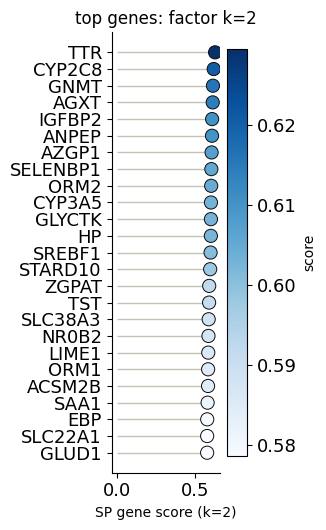

In [28]:
k = 2
N_TOP = 25

#scores = pd.Series(psc.varm["X_nmf"][:, k], index=psc.var_names, name="score")
## make score pandas using: phat_genes.loc[phat_genes["k"] == k].drop(columns="k")
scores = pd.Series(
    phat_genes.loc[phat_genes["k"] == k].drop(columns="k").set_index("SYMBOL")["corr"].sort_values(ascending=False),

) 
top_genes = (
    scores.sort_values(ascending=False)
    .head(N_TOP)
    .rename(index=psc.var["SYMBOL"])
    .sort_values()  # ascending so the highest score plots at the top
)

fig, ax = plt.subplots(figsize=(3.2, 5.4))
sca = ax.scatter(
    top_genes.values, np.arange(len(top_genes)),
    c=top_genes.values, cmap="Blues", s=90,
    edgecolors="#0b0b0b", linewidths=0.7, zorder=3,
)
ax.hlines(np.arange(len(top_genes)), 0, top_genes.values, 
color="#c3c2b7", linewidth=1, zorder=1)
ax.set_yticks(np.arange(len(top_genes)))
ax.set_yticklabels(top_genes.index, fontsize=13)      # gene names
ax.tick_params(axis="x", labelsize=13)                 # x-axis tick numbers
ax.set_xlabel(f"SP gene score (k={k})")
ax.set_title(f"top genes: factor k={k}")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
cbar = fig.colorbar(sca, ax=ax, label="score")  # colorbar label
cbar.ax.tick_params(labelsize=13)                      # colorbar tick numbers
fig.tight_layout()
plt.show()


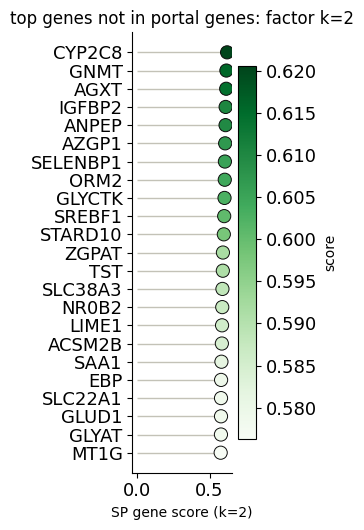

In [29]:
k = 2
N_TOP = 27

#scores = pd.Series(psc.varm["X_nmf"][:, k], index=psc.var_names, name="score")
## make score pandas using: phat_genes.loc[phat_genes["k"] == k].drop(columns="k")
scores = pd.Series(
    phat_genes.loc[phat_genes["k"] == k].drop(columns="k").set_index("SYMBOL")["corr"].sort_values(ascending=False),

) 
top_genes = (
    scores.sort_values(ascending=False)
    .head(N_TOP)
    .rename(index=psc.var["SYMBOL"])
    .sort_values()  # ascending so the highest score plots at the top
)

if k==2:
    top_genes_filtered = top_genes[~top_genes.index.isin(portal_genes)]
if k==6:
    top_genes_filtered = top_genes[~top_genes.index.isin(central_genes)]


fig, ax = plt.subplots(figsize=(3.2, 5.4))
sca = ax.scatter(
    top_genes_filtered.values, np.arange(len(top_genes_filtered)),
    c=top_genes_filtered.values, cmap="Greens", s=90,
    edgecolors="#0b0b0b", linewidths=0.7, zorder=3,
)
ax.hlines(np.arange(len(top_genes_filtered)), 0, top_genes_filtered.values, 
color="#c3c2b7", linewidth=1, zorder=1)
ax.set_yticks(np.arange(len(top_genes_filtered)))
ax.set_yticklabels(top_genes_filtered.index, fontsize=13)      # gene names
ax.tick_params(axis="x", labelsize=13)                 # x-axis tick numbers
ax.set_xlabel(f"SP gene score (k={k})")
ax.set_title(f"top genes not in {'portal genes' if k == 2 else 'central genes'}: factor k={k}")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
cbar = fig.colorbar(sca, ax=ax, label="score")  # colorbar label
cbar.ax.tick_params(labelsize=13)                      # colorbar tick numbers
fig.tight_layout()
plt.show()


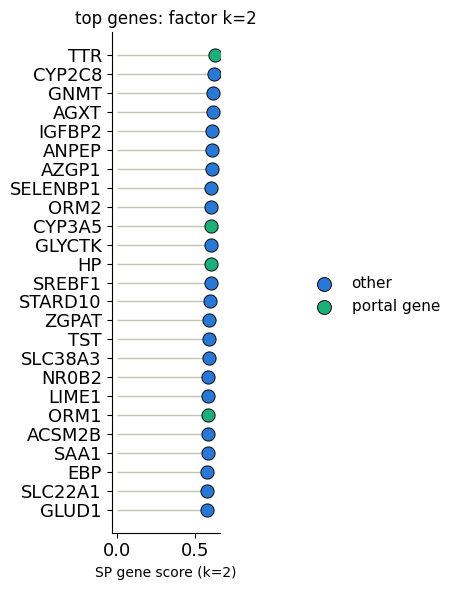

In [30]:
k = 2
N_TOP = 25

scores = phat_genes.loc[phat_genes["k"] == k].set_index("SYMBOL")["corr"]
top_genes = scores.sort_values(ascending=False).head(N_TOP).sort_values()  # ascending so highest plots at top

BASE_COLOR = "#2a78d6"       # blue — everything else
PORTAL_COLOR = "#1baf7a"     # green — portal genes
CENTRAL_COLOR = "#eb6834"    # orange — central genes

if k == 2:
    highlight_genes, highlight_color, highlight_label = portal_genes, PORTAL_COLOR, "portal gene"
elif k == 6:
    highlight_genes, highlight_color, highlight_label = central_genes, CENTRAL_COLOR, "central gene"

is_highlighted = top_genes.index.isin(highlight_genes)
y_pos = np.arange(len(top_genes))

fig, ax = plt.subplots(figsize=(3, 6))
ax.scatter(
    top_genes.values[~is_highlighted], y_pos[~is_highlighted],
    c=BASE_COLOR, s=90, edgecolors="#0b0b0b", linewidths=0.7, zorder=3, label="other",
)
ax.scatter(
    top_genes.values[is_highlighted], y_pos[is_highlighted],
    c=highlight_color, s=90, edgecolors="#0b0b0b", linewidths=0.7, zorder=3, label=highlight_label,
)
ax.hlines(y_pos, 0, top_genes.values, color="#c3c2b7", linewidth=1, zorder=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(top_genes.index, fontsize=13)      # gene names
ax.tick_params(axis="x", labelsize=13)                 # x-axis tick numbers
ax.set_xlabel(f"SP gene score (k={k})")
ax.set_title(f"top genes: factor k={k}")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

leg = fig.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=11)
for h in leg.legend_handles:
    h.set_sizes([100])

fig.tight_layout(rect=[0, 0, 0.8, 1])  # leave room on the right so the legend isn't clipped
plt.show()


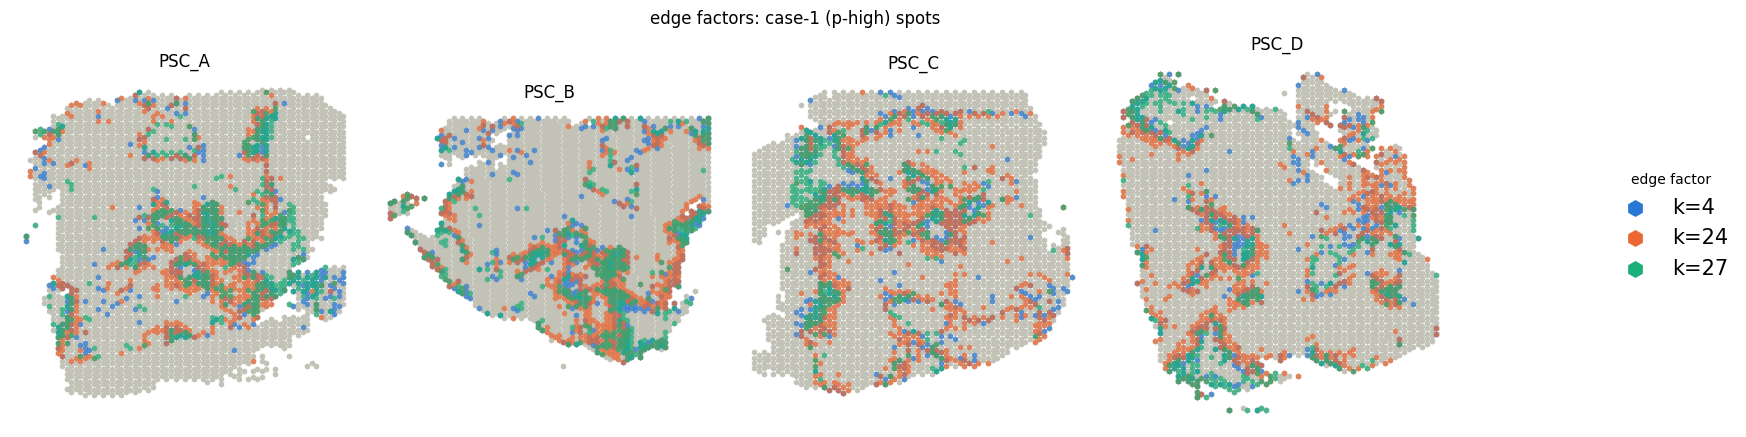

In [8]:
# visualize the three "edge" factor case-1 (p_hat-high) clusters together, on the PSC (case) samples only
EDGE_COLORS = {4: "#2a78d6", 24: "#eb6834", 27: "#1baf7a"}  # fixed categorical order, CVD-safe for overlapping scatter
BG_COLOR = "#c3c2b7"  # light grey background for spots not in any edge cluster

psc_case = psc[psc.obs["group"] != "CTL"].copy()
edge_samples = psc_case.obs["sample_id"].cat.remove_unused_categories().cat.categories.tolist()

fig, axes = plt.subplots(1, len(edge_samples), figsize=(4 * len(edge_samples), 4.5), squeeze=False)
axes = axes[0]

for ax, sample in zip(axes, edge_samples):
    sub = psc_case[psc_case.obs["sample_id"] == sample]
    xy = sub.obsm["spatial"]
    x, y = xy["x"].to_numpy(), xy["y"].to_numpy()

    ax.scatter(x, y, s=20, c=BG_COLOR, marker="h", linewidths=0)

    for k in edge:
        is_edge_k = sub.obsm[SP_FACT_PAT_STR.format(k=k)][sP.BIN_KEY].to_numpy()
        ax.scatter(
            x[is_edge_k], y[is_edge_k],
            s=20, c=EDGE_COLORS[k], alpha=0.7, marker="h", linewidths=0,
            label=f"k={k}",
        )

    ax.set_title(sample)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
leg = fig.legend(
    handles, labels,
    loc="center left", bbox_to_anchor=(1.0, 0.5),  # anchor left edge of legend at right edge of figure
    frameon=False, fontsize=15, title="edge factor",
)
for h in leg.legend_handles:   # matplotlib >=3.7; use leg.legendHandles on older versions
    h.set_sizes([150])          # bigger swatch dot
    h.set_alpha(1)               # full opacity, ignoring the plotted alpha=0.7

fig.suptitle("edge factors: case-1 (p-high) spots")
fig.tight_layout(rect=[0, 0, 0.92, 1])  # leave room on the right so the legend isn't clipped
plt.show()

fig.savefig(fig_dir / f"psc_edge_factors.pdf", dpi=300, bbox_inches="tight")


In [22]:
from functools import reduce

SIG_ADJ_PVAL = 0.05
MIN_LFC = 1.0          # >= 2-fold up in case-1 vs control
MIN_MEAN_COUNT = 0.5   # drop lowly-expressed genes so ranking isn't noise-driven
N_TOP = 5

psc_case = psc[psc.obs["group"] != "CTL"]

deg_by_k = {k: run_deg_groups(psc, k, "group", "CTL", SP_FACT_PAT_STR) for k in edge}

mean_expr_by_k = {}
for k in edge:
    is_case1 = psc_case.obsm[SP_FACT_PAT_STR.format(k=k)][sP.BIN_KEY].to_numpy()
    case1_counts = psc_case.layers["counts"][is_case1, :]
    mean_expr_by_k[k] = pd.Series(np.ravel(case1_counts.mean(axis=0)), index=psc_case.var_names)

sig_by_k = {}
for k in edge:
    d = deg_by_k[k].query(
        "cmp == 'case1_vs_control' and adj_pval < @SIG_ADJ_PVAL and lfc > @MIN_LFC"
    ).set_index("gene")
    expressed = mean_expr_by_k[k].reindex(d.index) > MIN_MEAN_COUNT
    named = ~psc.var["SYMBOL"].reindex(d.index).str.startswith("ENSG").fillna(True)  # drop unannotated placeholders
    sig_by_k[k] = d.loc[expressed & named, "lfc"].sort_values(ascending=False)

shared_ids = reduce(set.intersection, (set(s.index) for s in sig_by_k.values()))
unique_ids = {
    k: set(sig_by_k[k].index) - shared_ids - set.union(*(set(sig_by_k[k2].index) for k2 in edge if k2 != k))
    for k in edge
}

shared_mean_lfc = pd.concat([sig_by_k[k].reindex(shared_ids) for k in edge], axis=1).mean(axis=1)
shared_top = shared_mean_lfc.sort_values(ascending=False).head(N_TOP).index
shared = psc.var.loc[shared_top, "SYMBOL"].tolist()

unique = {}
for k in edge:
    top_ids = sig_by_k[k].loc[sig_by_k[k].index.isin(unique_ids[k])].head(N_TOP).index
    unique[k] = psc.var.loc[top_ids, "SYMBOL"].tolist()

print("shared:", shared)
print("unique:", unique)


KeyboardInterrupt: 

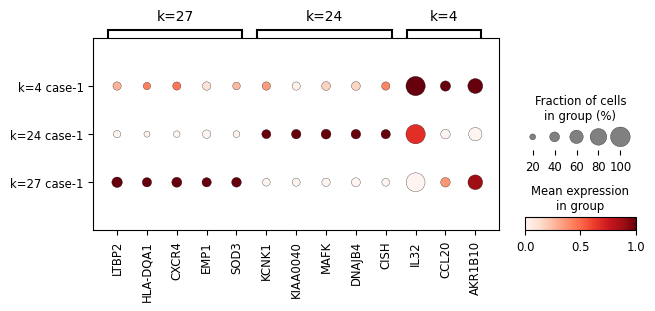

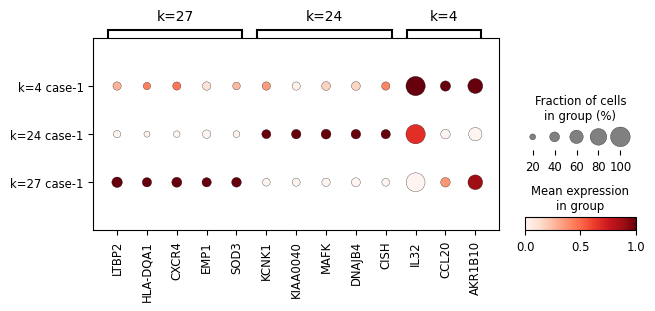

In [10]:
# expression of shared + factor-specific genes within each edge factor's case-1 spots
shared = ["HLA-B", "CD74", "TMSB4X", "IGFBP7"]

unique = {
    27: ["DCN", "COL1A2", "PTGDS", "C7", "COL6A2"],
    24: ["GPX3", "G6PC", "CFB", "HPD", "PCK1"],
    4:  [ "ANXA2", "UBD", "IL32"],
}

#n significant per factor: {4: 621, 24: 1179, 27: 677}
#n shared: 475   n unique: {4: 0, 24: 536, 27: 108}

shared =  ['XIST', 'CCL20', 'AKR1B10', 'APOA4', 'IL8']
unique =  {4: [ "IL32", 'CCL20', 'AKR1B10'], 
           24: ['KCNK1', 'KIAA0040', 'MAFK', 'DNAJB4', 'CISH'], 
           27: ['LTBP2', 'HLA-DQA1', 'CXCR4', 'EMP1', 'SOD3']}


psc_case = psc[psc.obs["group"] != "CTL"]

case1_adatas = {}
for k in edge:
    is_case1 = psc_case.obsm[SP_FACT_PAT_STR.format(k=k)][sP.BIN_KEY].to_numpy()
    case1_adatas[f"k={k} case-1"] = psc_case[is_case1].copy()

case1_adata = ad.concat(case1_adatas, label="edge_group", index_unique="-", merge="same")
case1_adata.obs["edge_group"] = pd.Categorical(
    case1_adata.obs["edge_group"], categories=list(case1_adatas.keys()), ordered=True
)


dp = sc.pl.dotplot(
    case1_adata,
    var_names={ "k=27": unique[27], 
               "k=24": unique[24], "k=4": unique[4]},
    groupby="edge_group",
    gene_symbols="SYMBOL",
    layer="counts",
    standard_scale="var",
    figsize=(7, 2.5),
    return_fig=True,
)
dp.savefig(fig_dir / "psc_edge_case1_dotplot-v2.pdf", dpi=300)
dp.show()


In [11]:
smoothmuscle = [7]
k = smoothmuscle[0]

bin_k = psc.obsm[SP_FACT_PAT_STR.format(k=k)][sP.BIN_KEY].to_numpy()

smoothmuscle_counts = (
    psc.obs
    .assign(**{f"k{k}_bin": bin_k})
    .groupby(["sample_id", "group"], observed=True)[f"k{k}_bin"]
    .agg(n_total="size", n_pass="sum")
    .assign(pct_pass=lambda d: (100 * d["n_pass"] / d["n_total"]).round(1))
    .reset_index()
)
smoothmuscle_counts


,sample_id,group,n_total,n_pass,pct_pass
0,CTL_A,CTL,2378,13,0.5
1,CTL_B,CTL,2349,11,0.5
2,CTL_C,CTL,2277,12,0.5
3,CTL_D,CTL,2265,17,0.8
4,PSC_A,PSC,3322,31,0.9
5,PSC_B,PSC,2670,21,0.8
6,PSC_C,PSC,3118,22,0.7
7,PSC_D,PSC,3174,39,1.2


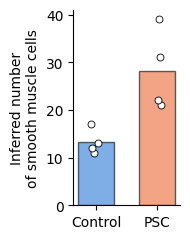

In [12]:
groups = ["CTL", "PSC"]
GROUP_LABELS = {"CTL": "Control", "PSC": "PSC"}
GROUP_COLORS = {"CTL": "#2a78d6", "PSC": "#eb6834"}

group_means = smoothmuscle_counts.groupby("group", observed=True)["n_pass"].mean().reindex(groups)

fig, ax = plt.subplots(figsize=(2, 2.5))
x_pos = np.arange(len(groups))
ax.bar(x_pos, group_means.values, color=[GROUP_COLORS[g] for g in groups], alpha=0.6, 
       width=0.6, zorder=2, edgecolor="black", linewidth=1)

rng = np.random.default_rng(0)
for i, g in enumerate(groups):
    vals = smoothmuscle_counts.loc[smoothmuscle_counts["group"] == g, "n_pass"].to_numpy()
    jitter = rng.uniform(-0.08, 0.08, size=len(vals))
    ax.scatter(
        np.full(len(vals), x_pos[i]) + jitter, vals,
        color="white", edgecolor='black',s=25, zorder=3, linewidths=0.6,
    )

ax.set_xticks(x_pos)
ax.set_xticklabels([GROUP_LABELS[g] for g in groups])
ax.set_ylabel("Inferred number\nof smooth muscle cells")
ax.set_title("")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()

fig.savefig(fig_dir / "psc_smoothmuscle_counts.pdf", dpi=300, bbox_inches="tight")


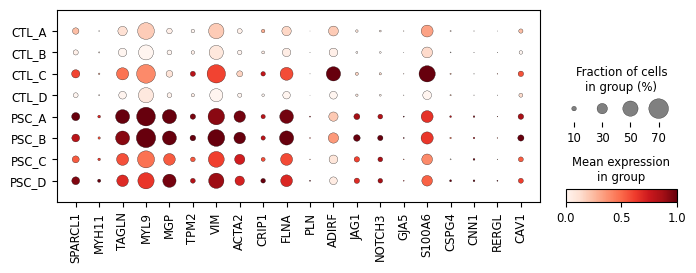

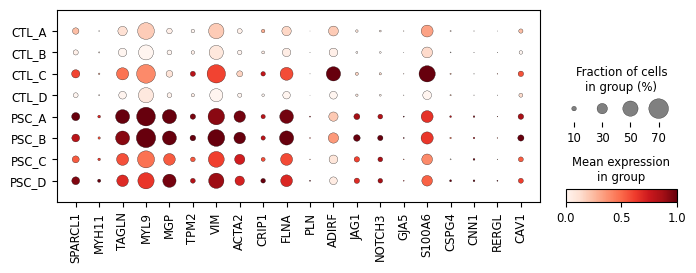

In [14]:
genes = [
    "SPARCL1", "MYH11", "TAGLN", "MYL9", "MGP",
    "TPM2", "VIM", "ACTA2", "CRIP1", "FLNA",
    "PLN", "ADIRF", "JAG1", "NOTCH3", "GJA5",
    "S100A6", "CSPG4", "CNN1", "RERGL", "CAV1"
]

dp = sc.pl.dotplot(
    psc,
    var_names=genes,
    groupby="sample_id",       # rows
    gene_symbols="SYMBOL",     # look genes up by SYMBOL since var index is Ensembl IDs
    layer="counts",            # raw counts, not the per-sample-scaled X
    standard_scale="var",      # scale each gene 0-1 across samples so color is comparable across genes
    figsize=(8, 2.5),
    return_fig=True,
)

dp.savefig(fig_dir / "psc_smoothmuscle_case1_dotplot.pdf", dpi=300)
dp.show()


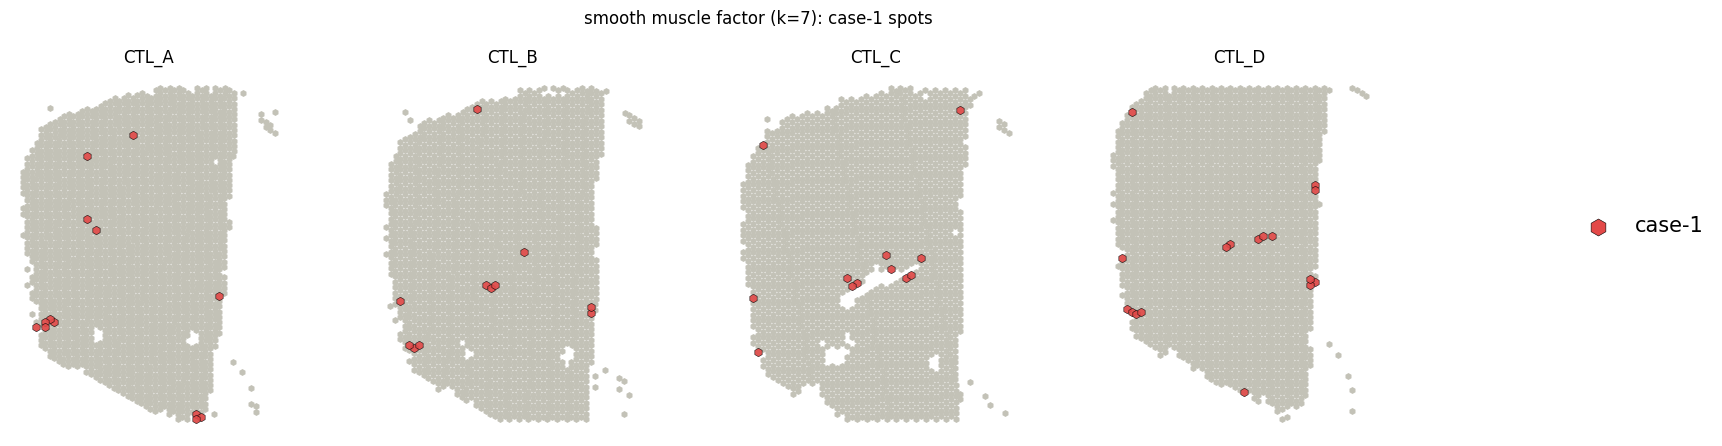

In [19]:
smoothmuscle = [7]
k = smoothmuscle[0]

BG_COLOR = "#c3c2b7"   # light grey background
FG_COLOR = "#e34948"   # red, case-1 spots

psc_case = psc[psc.obs["group"] != "PSC"].copy() ## change to "PSC" to see contorl samples
case_samples = psc_case.obs["sample_id"].cat.remove_unused_categories().cat.categories.tolist()

fig, axes = plt.subplots(1, len(case_samples), figsize=(4 * len(case_samples), 4.5), squeeze=False)
axes = axes[0]

for ax, sample in zip(axes, case_samples):
    sub = psc_case[psc_case.obs["sample_id"] == sample]
    xy = sub.obsm["spatial"]
    x, y = xy["x"].to_numpy(), xy["y"].to_numpy()
    is_case1 = sub.obsm[SP_FACT_PAT_STR.format(k=k)][sP.BIN_KEY].to_numpy()

    ax.scatter(x, y, s=25, c=BG_COLOR, marker="h", linewidths=0)
    ax.scatter(x[is_case1], y[is_case1], s=37, c=FG_COLOR, alpha=0.9, marker="h", 
               linewidths=0.4, label="case-1", edgecolors="black")

    ax.set_title(sample)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
leg = fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=15)
for h in leg.legend_handles:
    h.set_sizes([150])
    h.set_alpha(1)

fig.suptitle(f"smooth muscle factor (k={k}): case-1 spots")
fig.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()

#fig.savefig(fig_dir / f"psc_smoothmuscle_case1_spots.png", dpi=300, bbox_inches="tight")
fig.savefig(fig_dir / f"psc_smoothmuscle_control_spots.png", dpi=300, bbox_inches="tight")
